### Core Concepts: From Theory to Data

Statistical inference provides a framework for moving from observed data to meaningful conclusions about the underlying economic or statistical system. In practice, we observe a single realization of data, but our goal is to understand the broader process that generated it and to quantify the uncertainty in our conclusions. This requires linking theory and data through a sequence of concepts: the Data Generating Process (DGP) describes how data arise, the Central Limit Theorem (CLT) explains how estimators behave across repeated samples, and simulation methods such as Monte Carlo and bootstrap allow us to approximate this behavior in practice. Based on these ideas, confidence intervals are constructed to summarize the uncertainty surrounding estimated parameters. Together, these tools form a coherent pathway from theoretical assumptions to empirical inference.


| Concept                       | Role                          | Key Idea                                                                                           | Reference                                                |
| ----------------------------- | ----------------------------- | -------------------------------------------------------------------------------------------------- | -------------------------------------------------------- |
| CLT (Central Limit Theorem)   | Theoretical behavior          | Describes the sampling distribution of estimators (e.g., sample mean becomes approximately normal) | Casella & Berger (2002, Ch. 5); Hayashi (2000, Ch. 2)    |
| DGP (Data Generating Process) | Source of data                | The underlying stochastic process that generates the observed data                                 | Hayashi (2000, Ch. 1); Wooldridge (2010, Ch. 2)          |
| Monte Carlo                   | Simulate DGP                  | Uses assumed DGP to generate repeated samples and study estimator properties                       | Glasserman (2004); Kroese et al. (2011)                  |
| Bootstrap                     | Approximate DGP from data     | Resamples observed data to approximate the sampling distribution without knowing the true DGP      | Efron & Tibshirani (1993); Davison & Hinkley (1997)      |
| CI (Confidence Interval)      | Built from sampling under DGP | Uses sampling distribution (via CLT or simulation) to quantify uncertainty about parameters        | Casella & Berger (2002, Ch. 9); Wooldridge (2010, Ch. 4) |

---

### References

* Casella, G., & Berger, R. L. (2002). *Statistical Inference*.
* Hayashi, F. (2000). *Econometrics*.
* Wooldridge, J. M. (2010). *Econometric Analysis of Cross Section and Panel Data*.
* Efron, B., & Tibshirani, R. (1993). *An Introduction to the Bootstrap*.
* Davison, A. C., & Hinkley, D. V. (1997). *Bootstrap Methods and Their Application*.
* Glasserman, P. (2004). *Monte Carlo Methods in Financial Engineering*.
* Kroese, D. P., Taimre, T., & Botev, Z. I. (2011). *Handbook of Monte Carlo Methods*.


### Step 1: Central Limit Theorem (CLT)

The Central Limit Theorem (CLT) provides the theoretical foundation for statistical inference. It describes how estimators behave across repeated samples, even when the underlying data distribution is unknown.

Formally, for a sample mean:

$$
\bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i
$$

the CLT states that:

$$
\sqrt{n}(\bar{X} - \mu) \xrightarrow{d} \mathcal{N}(0, \sigma^2)
$$

or equivalently:

$$
\bar{X} \approx \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)
$$

as the sample size becomes large.

---

### General Form (for any estimator)

More generally, for a wide class of estimators:

$$
\sqrt{n}(\hat{\theta} - \theta) \xrightarrow{d} \mathcal{N}(0, \Sigma)
$$

This means that many estimators (not just the sample mean) are approximately normally distributed in large samples.

---

### Why the CLT is important

The CLT allows us to:

- Approximate the distribution of estimators
- Measure uncertainty using standard errors
- Construct confidence intervals
- Perform hypothesis testing

Without the CLT, we would not know how to quantify uncertainty from a single observed sample.

---

### Where the CLT is used

The CLT underlies most tools in statistical inference:

- Confidence intervals:
  $$
  \hat{\theta} \pm z_{\alpha/2} \cdot SE(\hat{\theta})
  $$

- Hypothesis testing (t-tests, z-tests)

- Regression and econometric models (OLS, VAR, SVAR)

- Impulse response confidence bands (asymptotic normality)

---

### Key Insight

The CLT introduces the concept of a **sampling distribution**. Although we observe only one sample, the CLT allows us to reason about how estimators would behave across many hypothetical samples generated by the same Data Generating Process (DGP).

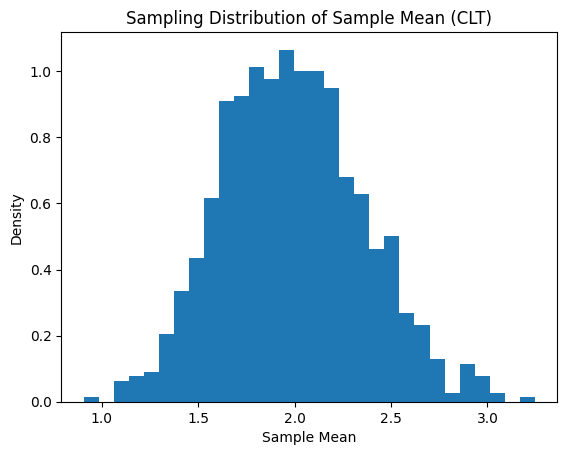

In [2]:
## CLT via Monte Carlo
import numpy as np
import matplotlib.pyplot as plt



np.random.seed(0)

# Parameters
n = 30
num_sim = 1000

means = []

# Monte Carlo simulation
for _ in range(num_sim):
    # Non-normal DGP (skewed distribution)
    sample = np.random.exponential(scale=2, size=n)
    
    # Compute estimator (sample mean)
    means.append(np.mean(sample))

# Plot sampling distribution
plt.hist(means, bins=30, density=True)
plt.title("Sampling Distribution of Sample Mean (CLT)")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.show()

### Step 2: Data Generating Process (DGP)

The Data Generating Process (DGP) describes the underlying stochastic mechanism that produces the observed data. In practice, the true DGP is unknown, but we assume that the data arise from some probabilistic structure.

Formally, we can write:

$$
X_1, X_2, \dots, X_n \sim F(\theta)
$$

where:
- $F(\theta)$ is the unknown distribution,
- $\theta$ represents parameters (e.g., mean, variance).

The key idea is that:
- Data are generated by a structured process, not arbitrarily
- We observe only one realization of this process
- Inference relies on imagining repeated samples from the same DGP

In empirical work, we specify an approximate model for the DGP and use data to estimate its parameters.

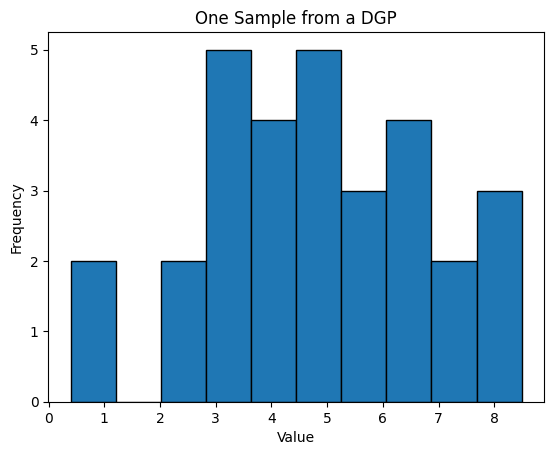

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# Define a DGP
mu = 5
sigma = 2
n = 30

# Generate one sample (what we observe in reality)
sample = np.random.normal(mu, sigma, n)

# Plot the sample
plt.hist(sample, bins=10, edgecolor='black')
plt.title("One Sample from a DGP")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

### Step 3: Monte Carlo Simulation

Monte Carlo simulation is a computational method used to study the behavior of estimators by repeatedly generating data from an assumed Data Generating Process (DGP).

Given a specified DGP, we:

1. Generate many synthetic datasets
2. Compute the estimator for each dataset
3. Analyze the distribution of these estimates

Formally, if the DGP is known:

$$
X_1, \dots, X_n \sim F(\theta)
$$

we simulate:

$$
\hat{\theta}^{(1)}, \hat{\theta}^{(2)}, \dots, \hat{\theta}^{(M)}
$$

across many repetitions.

---

### Purpose

Monte Carlo allows us to:

- Approximate the sampling distribution of estimators
- Evaluate bias, variance, and consistency
- Verify theoretical results such as the Central Limit Theorem
- Study finite-sample behavior when theory is difficult

---

### Key Insight

Monte Carlo creates an artificial version of the repeated sampling world assumed in statistical theory, allowing us to observe how estimators behave across many samples generated from the same DGP.

Mean of estimates: 4.991260962769318
Variance of estimates: 0.142345152206448


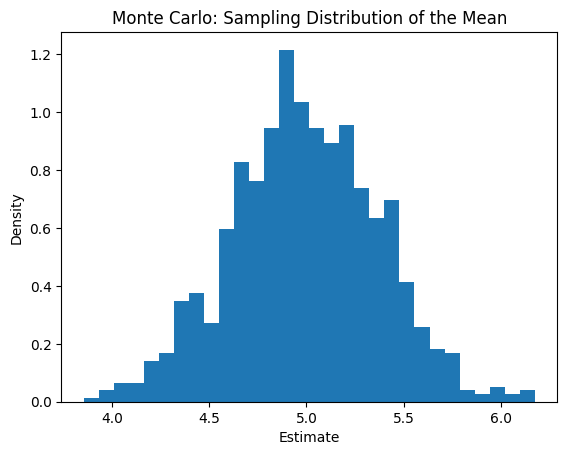

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# True DGP parameters
mu = 5
sigma = 2
n = 30
num_sim = 1000

estimates = []

# Monte Carlo loop
for _ in range(num_sim):
    sample = np.random.normal(mu, sigma, n)  # DGP
    theta_hat = np.mean(sample)              # estimator
    estimates.append(theta_hat)

# Analyze results
print("Mean of estimates:", np.mean(estimates))
print("Variance of estimates:", np.var(estimates))

# Plot sampling distribution
plt.hist(estimates, bins=30, density=True)
plt.title("Monte Carlo: Sampling Distribution of the Mean")
plt.xlabel("Estimate")
plt.ylabel("Density")
plt.show()

                 Concept     Value
0          True Mean (μ)  5.000000
1       Average Estimate  4.991261
2                   Bias -0.008739
3     Empirical Std (SE)  0.377287
4         Theoretical SE  0.365148
5  Variance of Estimates  0.142345


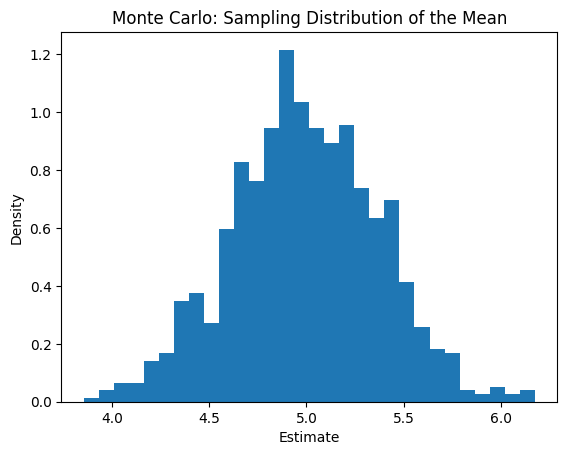

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(0)

# True DGP parameters
mu = 5
sigma = 2
n = 30
num_sim = 1000

estimates = []

# Monte Carlo loop (simulate repeated samples)
for _ in range(num_sim):
    sample = np.random.normal(mu, sigma, n)   # DGP
    theta_hat = np.mean(sample)               # estimator
    estimates.append(theta_hat)

# Convert to array
estimates = np.array(estimates)

# --- Purpose 1: Approximate sampling distribution ---
mean_est = np.mean(estimates)

# --- Purpose 2: Evaluate variance ---
var_est = np.var(estimates)
std_est = np.std(estimates)

# --- Purpose 3: Compare with theory (CLT) ---
theoretical_se = sigma / np.sqrt(n)

# --- Purpose 4: Check bias ---
bias = mean_est - mu

# Create results table
results = pd.DataFrame({
    "Concept": [
        "True Mean (μ)",
        "Average Estimate",
        "Bias",
        "Empirical Std (SE)",
        "Theoretical SE",
        "Variance of Estimates"
    ],
    "Value": [
        mu,
        mean_est,
        bias,
        std_est,
        theoretical_se,
        var_est
    ]
})

print(results)

# Plot sampling distribution
plt.hist(estimates, bins=30, density=True)
plt.title("Monte Carlo: Sampling Distribution of the Mean")
plt.xlabel("Estimate")
plt.ylabel("Density")
plt.show()

### Step 4: Bootstrap

In practice, the true Data Generating Process (DGP) is unknown, so we cannot simulate new samples directly from it. The bootstrap provides a solution by approximating the DGP using the observed data.

The key idea is:

- Treat the observed sample as a proxy for the population
- Generate new samples by resampling (with replacement) from the data
- Recompute the estimator for each resampled dataset

Formally, given observed data:

$$
X_1, X_2, \dots, X_n
$$

we generate bootstrap samples:

$$
X_1^*, X_2^*, \dots, X_n^*
$$

and compute:

$$
\hat{\theta}^* = g(X_1^*, \dots, X_n^*)
$$

repeatedly.

---

### Purpose

Bootstrap allows us to:

- Approximate the sampling distribution of an estimator
- Estimate standard errors without knowing the true DGP
- Construct confidence intervals
- Perform inference in complex models

---

### Key Insight

The bootstrap replaces the unknown DGP with the empirical distribution of the data, allowing us to simulate repeated sampling using only the observed dataset.

                    Purpose     Value
0         Original Estimate  5.885713
1            Bootstrap Mean  5.894717
2  Bootstrap Standard Error  0.397224
3           CI Lower (2.5%)  5.107088
4          CI Upper (97.5%)  6.666468


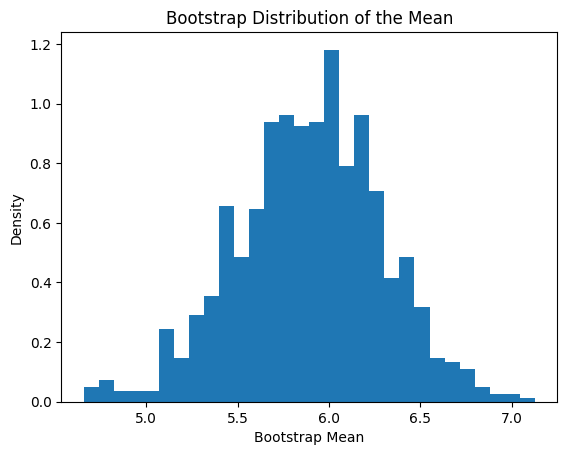

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(0)

# One observed sample (real-world situation)
n = 30
sample = np.random.normal(5, 2, n)

# Bootstrap
num_boot = 1000
boot_means = []

for _ in range(num_boot):
    boot_sample = np.random.choice(sample, size=n, replace=True)
    boot_means.append(np.mean(boot_sample))

boot_means = np.array(boot_means)

# --- Purpose 1: Approximate sampling distribution ---
boot_mean = np.mean(boot_means)

# --- Purpose 2: Estimate standard error ---
boot_se = np.std(boot_means)

# --- Purpose 3: Construct confidence interval ---
ci_lower, ci_upper = np.percentile(boot_means, [2.5, 97.5])

# --- Purpose 4: Compare with original estimate ---
original_mean = np.mean(sample)

# Results table
results = pd.DataFrame({
    "Purpose": [
        "Original Estimate",
        "Bootstrap Mean",
        "Bootstrap Standard Error",
        "CI Lower (2.5%)",
        "CI Upper (97.5%)"
    ],
    "Value": [
        original_mean,
        boot_mean,
        boot_se,
        ci_lower,
        ci_upper
    ]
})

print(results)

# Plot bootstrap distribution
plt.hist(boot_means, bins=30, density=True)
plt.title("Bootstrap Distribution of the Mean")
plt.xlabel("Bootstrap Mean")
plt.ylabel("Density")
plt.show()

### Bootstrap vs Monte Carlo

Both Bootstrap and Monte Carlo methods are used to study the sampling distribution of estimators, but they differ in how they generate repeated samples.

| Aspect               | Monte Carlo (MC)                           | Bootstrap                                       |
| -------------------- | ------------------------------------------ | ----------------------------------------------- |
| Core Idea            | Simulate data from a known DGP             | Resample from observed data                     |
| Source of Data       | Assumed true model (DGP)                   | Empirical distribution of the sample            |
| Requirement          | Requires specifying the DGP                | Does not require knowing the DGP                |
| Goal                 | Study theoretical properties of estimators | Perform inference with real data                |
| Sampling             | Generate new independent datasets          | Resample with replacement from the same dataset |
| Standard Error       | Computed from simulated samples            | Estimated from bootstrap samples                |
| Confidence Intervals | Based on simulated distribution            | Based on bootstrap percentiles                  |
| Use Case             | Simulation studies, theory validation      | Empirical analysis, real-world data             |
| Limitation           | Depends on correct DGP specification       | Depends on sample representing population       |

---

### Key Insight

* **Monte Carlo** answers: *“What happens if the true model is known?”*
* **Bootstrap** answers: *“What can we learn when the true model is unknown?”*

---

### References

* Efron, B., & Tibshirani, R. (1993). *An Introduction to the Bootstrap*.
* Davison, A. C., & Hinkley, D. V. (1997). *Bootstrap Methods and Their Application*.
* Glasserman, P. (2004). *Monte Carlo Methods in Financial Engineering*.
* Kroese, D. P., Taimre, T., & Botev, Z. I. (2011). *Handbook of Monte Carlo Methods*.


### Step 5: Confidence Intervals (CI)

Confidence intervals provide a practical way to quantify uncertainty about unknown parameters using the sampling distribution of an estimator.

Given an estimator $\hat{\theta}$, a $(1-\alpha)$ confidence interval is constructed as:

$$
\hat{\theta} \pm z_{\alpha/2} \cdot SE(\hat{\theta})
$$

or, for the sample mean with unknown variance:

$$
\bar{X} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}
$$

---

### Intuition: The “Machine” View

Confidence intervals are best understood as a **procedure**, not a fixed object.

* **Before data → “I know how the machine works”**
  We have a rule (derived from the Central Limit Theorem) that tells us how to construct an interval for any possible sample. At this stage, the sample mean $\bar{X}$ is random, so the interval itself is also random.

* **After data → “I pressed the machine once”**
  We observe one specific sample, compute $\bar{X}$, and obtain one fixed interval. The randomness disappears because the data are now fixed.

---

### Interpretation

A confidence interval does **not** mean that the parameter is random. Instead:

* The randomness comes from the sampling process
* The interval is one realization of a broader procedure

If we repeated the sampling process many times and constructed an interval each time:

* Approximately $(1-\alpha)%$ of those intervals would contain the true parameter

This is why probability statements apply to the **procedure**, not to a single computed interval.

---

### Connection to Previous Steps

Confidence intervals combine all previous concepts:

* **CLT** → provides the approximate distribution of the estimator
* **DGP** → defines how repeated samples are generated
* **Monte Carlo** → simulates this repeated sampling world
* **Bootstrap** → approximates it using observed data

---

### Methods to Construct Confidence Intervals

1. **Analytical (CLT-based):**
   $$
   \hat{\theta} \pm z_{\alpha/2} \cdot SE(\hat{\theta})
   $$

2. **Monte Carlo (simulation-based):**

   * Use simulated estimates
   * Take percentiles of the distribution

3. **Bootstrap (data-driven):**
   $$
   [\hat{\theta}^*_{2.5\%}, \hat{\theta}^*_{97.5\%}]
   $$

---

### Key Insight

Confidence intervals translate the abstract concept of a sampling distribution into a concrete range of plausible values, summarizing uncertainty in a way that is both interpretable and grounded in statistical theory.

---

### Final Takeaway

Confidence intervals are the final output of statistical inference, combining theory (CLT), assumptions (DGP), and computational tools (Monte Carlo and bootstrap) into a single, coherent measure of uncertainty.


        Quantity     Value
0    Sample Mean  5.039847
1       CI Lower  4.347442
2       CI Upper  5.732253
3  Coverage Rate  0.938000


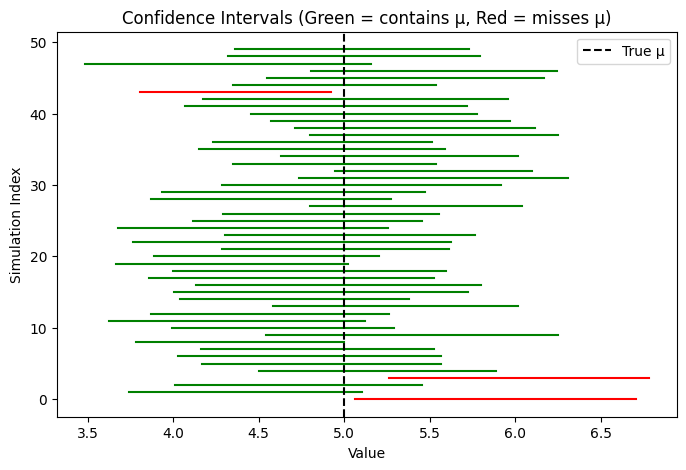

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

np.random.seed(0)

# True parameters (unknown in real life)
mu = 5
sigma = 2

n = 30
num_sim = 1000

intervals = []
cover_count = 0

# --- "Machine" repeated many times ---
for _ in range(num_sim):
    sample = np.random.normal(mu, sigma, n)
    
    x_bar = np.mean(sample)
    s = np.std(sample, ddof=1)
    
    t_crit = stats.t.ppf(0.975, df=n-1)
    
    ci_lower = x_bar - t_crit * s / np.sqrt(n)
    ci_upper = x_bar + t_crit * s / np.sqrt(n)
    
    intervals.append((ci_lower, ci_upper))
    
    # Check coverage
    if ci_lower <= mu <= ci_upper:
        cover_count += 1

# --- One observed sample ("press the machine once") ---
sample = np.random.normal(mu, sigma, n)
x_bar = np.mean(sample)
s = np.std(sample, ddof=1)

t_crit = stats.t.ppf(0.975, df=n-1)

ci_lower = x_bar - t_crit * s / np.sqrt(n)
ci_upper = x_bar + t_crit * s / np.sqrt(n)

# Results table
results = pd.DataFrame({
    "Quantity": [
        "Sample Mean",
        "CI Lower",
        "CI Upper",
        "Coverage Rate"
    ],
    "Value": [
        x_bar,
        ci_lower,
        ci_upper,
        cover_count / num_sim
    ]
})

print(results)

# --- Plot few intervals (visual intuition) ---
plt.figure(figsize=(8,5))

for i in range(50):  # show first 50 intervals
    low, high = intervals[i]
    color = 'green' if (low <= mu <= high) else 'red'
    plt.plot([low, high], [i, i], color=color)

plt.axvline(mu, color='black', linestyle='--', label='True μ')
plt.title("Confidence Intervals (Green = contains μ, Red = misses μ)")
plt.xlabel("Value")
plt.ylabel("Simulation Index")
plt.legend()
plt.show()